In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [5]:
import pandas as pd
df = pd.read_csv("../data/processed/cleaned_data.csv")
features = [
    "sessions_per_week",
    "avg_session_duration_min",
    "daily_active_minutes",
    "engagement_score",
    "account_age_days"
]

X = df[features]

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

1. Train Final KMeans Model

In [7]:
from sklearn.cluster import KMeans

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [22]:
cluster_summary = df.groupby("cluster").mean(numeric_only=True)

cluster_summary.to_csv("../reports/cluster_summary.csv")

2. PCA Dimensionality Reduction

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

3. PCA Visualization

In [12]:
import matplotlib.pyplot as plt

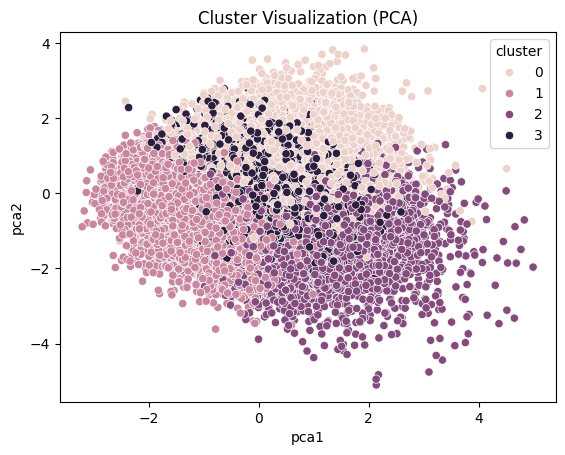

In [13]:
import seaborn as sns

df["pca1"] = pca_components[:,0]
df["pca2"] = pca_components[:,1]

sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster")
plt.title("Cluster Visualization (PCA)")
plt.show()

Measures how well users fit within their cluster.

In [16]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df["cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.15193861861388552
